# 02 - Vehicle Detection (YOLOv8)

Runs pretrained YOLOv8 over the extracted frames in `data/frames/`, filters detections to vehicle classes, and produces:

1. `data/processed/vehicle_counts.csv` — per-frame vehicle counts
2. `data/processed/detections_raw.csv` — per-detection bounding boxes
3. Precision / Recall / mAP computed against `gt/gt.txt` for the validation and test splits

**Split:** S01, S03, S04 = train · S02 = validation · S05 = test (S06 excluded — no ground truth `gt/` folder).

In [1]:
import csv
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from ultralytics import YOLO


In [2]:
raw_dir = Path("../data/raw")
frames_dir = Path("../data/frames")
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

model_name = "yolov8n.pt"
conf_thresh = 0.5
iou_thresh_nms = 0.45
iou_thresh_eval = 0.5

vehicle_class_ids = {2: "car", 3: "motorcycle", 5: "bus", 7: "truck"}

scene_split = {
    "S01": "train", "S03": "train", "S04": "train",
    "S02": "val",
    "S05": "test",
}

gt_frame_offset = 1

In [3]:
model = YOLO(model_name)

In [4]:
def detect_vehicles(frame_path: Path):
    """Run YOLOv8 on a single frame, return list of vehicle detections as
    (class_name, confidence, x1, y1, x2, y2)."""
    results = model(str(frame_path), conf=conf_thresh, iou=iou_thresh_nms, verbose=False)[0]

    detections = []
    for box in results.boxes:
        cls_id = int(box.cls.item())
        if cls_id not in vehicle_class_ids:
            continue
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = float(box.conf.item())
        detections.append((vehicle_class_ids[cls_id], conf, x1, y1, x2, y2))
    return detections

In [5]:
def process_camera(scene_id: str, camera_id: str, camera_frame_dir: Path,
                    frame_metadata: pd.DataFrame, count_rows: list, detection_rows: list):
    """Run detection over every frame for one camera, appending results in place
    to count_rows and detection_rows."""
    split = scene_split.get(scene_id, "excluded")
    cam_meta = frame_metadata[
        (frame_metadata["scene_id"] == scene_id) & (frame_metadata["camera_id"] == camera_id)
    ]

    for _, row in tqdm(cam_meta.iterrows(), total=len(cam_meta), desc=f"{scene_id}/{camera_id}", leave=False):
        frame_path = camera_frame_dir / row["frame_file"]
        if not frame_path.exists():
            continue

        detections = detect_vehicles(frame_path)

        count_rows.append({
            "scene_id": scene_id,
            "camera_id": camera_id,
            "split": split,
            "frame_file": row["frame_file"],
            "source_frame_idx": row["source_frame_idx"],
            "timestamp_sec": row["timestamp_sec"],
            "vehicle_count": len(detections),
        })

        for cls_name, conf, x1, y1, x2, y2 in detections:
            detection_rows.append({
                "scene_id": scene_id,
                "camera_id": camera_id,
                "split": split,
                "frame_file": row["frame_file"],
                "source_frame_idx": row["source_frame_idx"],
                "class": cls_name,
                "confidence": conf,
                "x1": x1, "y1": y1, "x2": x2, "y2": y2,
            })

In [6]:
count_rows = []
detection_rows = []

for scene_dir in sorted(frames_dir.iterdir()):
    scene_id = scene_dir.name
    if scene_id not in scene_split:
        continue

    metadata_path = scene_dir.parent / "frame_metadata.csv"
    if not metadata_path.exists():
        metadata_path = frames_dir / "frame_metadata.csv"
    frame_metadata = pd.read_csv(metadata_path)

    for camera_dir in sorted(scene_dir.iterdir()):
        if not camera_dir.is_dir():
            continue
        camera_id = camera_dir.name
        process_camera(scene_id, camera_id, camera_dir, frame_metadata, count_rows, detection_rows)

vehicle_counts = pd.DataFrame(count_rows)
detections_raw = pd.DataFrame(detection_rows)

vehicle_counts.to_csv(processed_dir / "vehicle_counts.csv", index=False)
detections_raw.to_csv(processed_dir / "detections_raw.csv", index=False)

print(f"Frames processed: {len(vehicle_counts)}")
print(f"Vehicle detections: {len(detections_raw)}")
print(f"Saved to {processed_dir}")

S01/c001:   0%|          | 0/196 [00:00<?, ?it/s]

Frames processed: 11721
Vehicle detections: 47554
Saved to ..\data\processed


In [7]:
def load_gt(gt_path: Path):
    """Convert gt.txt into {frame_id: [(x1, y1, x2, y2), ...]}."""
    gt_by_frame = {}
    if not gt_path.exists():
        return gt_by_frame

    with open(gt_path, "r") as f:
        for line in f:
            parts = line.strip().split(",")
            if len(parts) < 6:
                continue
            frame_id, _obj_id, x, y, w, h = (float(p) for p in parts[:6])
            frame_id = int(frame_id)
            box = (x, y, x + w, y + h)
            gt_by_frame.setdefault(frame_id, []).append(box)
    return gt_by_frame

In [8]:
def compute_iou(box_a, box_b):
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b

    inter_x1, inter_y1 = max(xa1, xb1), max(ya1, yb1)
    inter_x2, inter_y2 = min(xa2, xb2), min(ya2, yb2)
    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)

    area_a = (xa2 - xa1) * (ya2 - ya1)
    area_b = (xb2 - xb1) * (yb2 - yb1)
    union = area_a + area_b - inter_area

    return inter_area / union if union > 0 else 0.0

In [9]:
def evaluate_camera(scene_id: str, camera_id: str, camera_detections: pd.DataFrame):
    gt_matches = list(raw_dir.rglob(f"{scene_id}/{camera_id}/gt/gt.txt"))
    gt_path = gt_matches[0] if gt_matches else (raw_dir / scene_id / camera_id / "gt" / "gt.txt")
    gt_by_frame = load_gt(gt_path)
    total_gt = sum(len(v) for v in gt_by_frame.values())

    cam_detections = camera_detections.sort_values("confidence", ascending=False)
    matched_flags = []

    claimed = {frame_id: [False] * len(boxes) for frame_id, boxes in gt_by_frame.items()}

    for _, det in cam_detections.iterrows():
        gt_frame_id = int(det["source_frame_idx"]) + gt_frame_offset
        det_box = (det["x1"], det["y1"], det["x2"], det["y2"])

        gt_boxes = gt_by_frame.get(gt_frame_id, [])
        best_iou, best_idx = 0.0, -1
        for i, gt_box in enumerate(gt_boxes):
            if claimed[gt_frame_id][i]:
                continue
            iou = compute_iou(det_box, gt_box)
            if iou > best_iou:
                best_iou, best_idx = iou, i

        if best_iou >= iou_thresh_eval:
            claimed[gt_frame_id][best_idx] = True
            matched_flags.append(True)   # true positive
        else:
            matched_flags.append(False)  # false positive

    return matched_flags, total_gt

In [10]:
def compute_ap(matched_flags: list, total_gt: int):
    if total_gt == 0 or len(matched_flags) == 0:
        return 0.0, 0.0, 0.0

    tp_cum = np.cumsum(matched_flags)
    fp_cum = np.cumsum([not m for m in matched_flags])

    precisions = tp_cum / (tp_cum + fp_cum)
    recalls = tp_cum / total_gt

    ap = 0.0
    for t in np.linspace(0, 1, 11):
        p_at_t = precisions[recalls >= t].max() if np.any(recalls >= t) else 0.0
        ap += p_at_t / 11

    final_precision = precisions[-1]
    final_recall = recalls[-1]
    return final_precision, final_recall, ap

In [11]:
def evaluate_split(split_name: str, detections_df: pd.DataFrame):
    split_detections = detections_df[detections_df["split"] == split_name]

    all_flags, total_gt_all = [], 0
    per_camera_results = []

    for (scene_id, camera_id), cam_detections in split_detections.groupby(["scene_id", "camera_id"]):
        flags, total_gt = evaluate_camera(scene_id, camera_id, cam_detections)
        precision, recall, ap = compute_ap(flags, total_gt)
        per_camera_results.append({
            "scene_id": scene_id, "camera_id": camera_id,
            "precision": precision, "recall": recall, "ap": ap, "n_gt": total_gt,
        })
        all_flags.extend(flags)
        total_gt_all += total_gt

    overall_precision, overall_recall, overall_map = compute_ap(all_flags, total_gt_all)
    per_camera_df = pd.DataFrame(per_camera_results)

    print(f"\n{split_name.upper()} — overall precision: {overall_precision:.3f}, "
          f"recall: {overall_recall:.3f}, mAP@{iou_thresh_eval}: {overall_map:.3f}")

    return per_camera_df, overall_precision, overall_recall, overall_map

In [12]:
val_results, val_p, val_r, val_map = evaluate_split("val", detections_raw)
test_results, test_p, test_r, test_map = evaluate_split("test", detections_raw)

summary = pd.DataFrame([
    {"split": "val", "precision": val_p, "recall": val_r, "map": val_map},
    {"split": "test", "precision": test_p, "recall": test_r, "map": test_map},
])
summary.to_csv(processed_dir / "detection_evaluation_summary.csv", index=False)

val_results.to_csv(processed_dir / "detection_evaluation_val_per_camera.csv", index=False)
test_results.to_csv(processed_dir / "detection_evaluation_test_per_camera.csv", index=False)

summary


VAL — overall precision: 0.437, recall: 0.067, mAP@0.5: 0.076

TEST — overall precision: 0.356, recall: 0.070, mAP@0.5: 0.091


,split,precision,recall,map
0,val,0.436717,0.066520,0.075758
1,test,0.355769,0.069514,0.090909


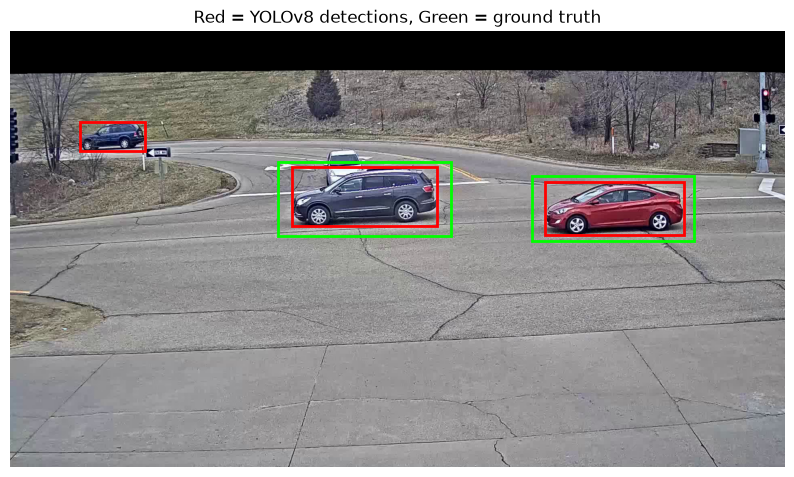

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sample_scene, sample_camera = "S02", "c007"  # adjust to a camera you know has gt
sample_dets = detections_raw[(detections_raw.scene_id == sample_scene) & (detections_raw.camera_id == sample_camera)]
sample_frame_idx = sample_dets["source_frame_idx"].iloc[0]

gt_matches = list(raw_dir.rglob(f"{sample_scene}/{sample_camera}/gt/gt.txt"))
gt_by_frame = load_gt(gt_matches[0])
gt_boxes = gt_by_frame.get(int(sample_frame_idx) + gt_frame_offset, [])

frame_file = sample_dets["frame_file"].iloc[0]
img = cv2.cvtColor(cv2.imread(str(frames_dir / sample_scene / sample_camera / frame_file)), cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)
for _, d in sample_dets[sample_dets.source_frame_idx == sample_frame_idx].iterrows():
    ax.add_patch(patches.Rectangle((d.x1, d.y1), d.x2 - d.x1, d.y2 - d.y1, linewidth=2, edgecolor="red", facecolor="none"))
for (x1, y1, x2, y2) in gt_boxes:
    ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="lime", facecolor="none"))
plt.title("Red = YOLOv8 detections, Green = ground truth")
plt.axis("off")
plt.show()